In [53]:
import torch
import torchvision
import torchvision.transforms as transforms

In [54]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Grayscale(num_output_channels=1)]
    )

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='/Users/avaldivia/Documents/GitHub/Split-Learning/CIFAR-10', 
                                        train     = True,
                                        download  = True, 
                                        transform = transform)

trainloader = torch.utils.data.DataLoader(trainset, 
                                          batch_size  = batch_size,
                                          shuffle     = True, 
                                          num_workers = 1)

testset = torchvision.datasets.CIFAR10(root  ='/Users/avaldivia/Documents/GitHub/Split-Learning/CIFAR-10', 
                                       train     = False,
                                       download  = True, 
                                       transform = transform)

testloader = torch.utils.data.DataLoader(testset, 
                                         batch_size = batch_size,
                                         shuffle    = False, 
                                         num_workers= 1)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

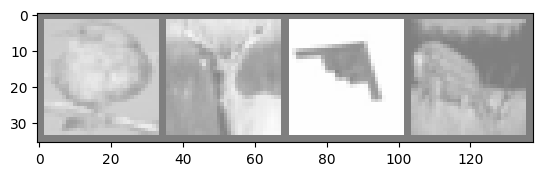

bird  deer  plane deer 


In [55]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter) # Next batch which is of size 4

imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [65]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        
        # Linear Layer
        self.fc1   = nn.Linear(16 * 5 * 5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
net.conv1

Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))

In [79]:
torch.randn(128).shape

torch.Size([128])

In [72]:
sample = images[0]
sample.shape

torch.Size([1, 32, 32])

In [73]:
x = net.pool(F.relu(net.conv1(sample)))
print(x.shape)
x = net.pool(F.relu(net.conv2(x)))
print(x.shape)

torch.Size([6, 14, 14])
torch.Size([16, 5, 5])


In [71]:
x.shape

torch.Size([16, 5, 5])

In [57]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [58]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        # zero the parameter gradients
        optimizer.zero_grad()
        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.301
[1,  4000] loss: 2.241
[1,  6000] loss: 2.121
[1,  8000] loss: 1.967
[1, 10000] loss: 1.854
[1, 12000] loss: 1.780
[2,  2000] loss: 1.715
[2,  4000] loss: 1.684
[2,  6000] loss: 1.670
[2,  8000] loss: 1.624
[2, 10000] loss: 1.609
[2, 12000] loss: 1.610
Finished Training


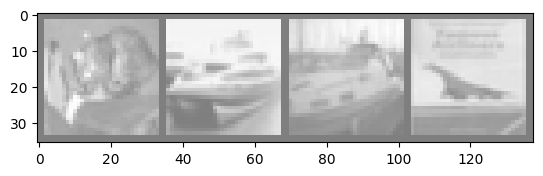

GroundTruth:  cat   ship  ship  plane


In [59]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [ ]:
sample = images[0]

torch.Size([1, 32, 32])

In [61]:
conv_out = net.conv1(sample)
filter1 = net.conv1.weight[0]
net.conv1(sample).shape

torch.Size([6, 28, 28])

In [62]:
outputs = net(images)
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  bird  ship  ship  plane
